# Evaluering av modellar

Modellar i statistikk og maskinlæring er tilfeldige konstruksjonar,
dvs. dei er like tilfeldige som datasettet som ligg til grunn.
Om me gjer nye observasjonar, vil dei se annleis ut, og me får ein
annan modell.

Dette ser me tydleg i meiningsmålingar.  Ofte er der fleire byrå
ut og gjer meiningsmålingar på same tid, og dei bruker dei same
statistiske metodane.  Likevel får dei forskjellige resultat, og
dei treff sjelden valresultatet presist.

Ein modell, som t.d. den lineære diskriminanten som me fann
i den førre øvinga ([[Fisher Linear Discriminant in sklearn]]), gjev ei optimal skildring av datasettet som det er trent på.
Det som er interessant er derimot kor godt det skildrar resten
av populasjonen og kor godt det kan predikera nye og hittil ukjende
data.  Det finn me berre ut ved å testa.

Her skal me gå gjennom eit enkelt og standardisert testlaup,
der me evaluerer modellen som me fann i den førre øvinga.

## Datasettet

Lat oss fyrst lasta datasettet på same måte som sist.  Me 
importerer òg dei same biblioteka som me brukte sist.

In [17]:
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np
iris = datasets.load_iris()

Me har ikkje fleire data enn det eine settet.  For å kunne evaluera
modellen må me difor halda tilbake ein del av datasettet til å testa
på.  Dette testsettet kan me ikkje bruka i treninga.
Ein vanleg tommelfingerregel er å bruka 20% av datasettet til testing
og 80% til trening.

::: {admonition} Merknad
Dette er ein tommelfingerregel.  Dersom du er kjend med estimering
og hypotesetesting frå statistikk, so kan du kanskje rekna ut kor
mange datapunkt du treng i testsettet for å få eit statistisk
signifikant resultat. Det er naudsynt for å kunna vita kor mykje
me kan stola på modellen, men her skal me nøya oss med tommelfingerregelen.

Der større testsett gjev ein meir påliteleg evaluering, vil større 
treningssett gje ein betre modell.  Det er eit dilemma.
:::

Når me deler datasettet vil me normalt syta for at klassene er
likt representerte i trenings- og testsettet.  Her har vi 50
blomar frå kva klasse, og vil då ta 40 frå kvar til testsettet.
Me tek også ut berre dei to fyrste søylene, akkurat som sist.

In [18]:
trening1 = iris.data[:40,:2]
trening2 = iris.data[50:90,:2]
trening3 = iris.data[100:140,:2]
test1 = iris.data[40:50,:2]
test2 = iris.data[90:100,:2]
test3 = iris.data[140:,:2]

trening = np.vstack( [ trening1, trening2, trening3 ] )
test = np.vstack( [ test1, test2, test3 ] )

Her bruker me seks variablar for å dela kvar klasse i 40+10 
rader, før me stablar saman tre delsett til test- og tremingssettet.
Me bruker numpy-funksjonen `vstack` som står for *vertical stack` 
til å setja saman matrisene.
Me kan sjekka:

In [19]:
print( "TRENING" )
print(trening)
print( "TEST" )
print(test)

TRENING
[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]
 [5.4 3.9]
 [4.6 3.4]
 [5.  3.4]
 [4.4 2.9]
 [4.9 3.1]
 [5.4 3.7]
 [4.8 3.4]
 [4.8 3. ]
 [4.3 3. ]
 [5.8 4. ]
 [5.7 4.4]
 [5.4 3.9]
 [5.1 3.5]
 [5.7 3.8]
 [5.1 3.8]
 [5.4 3.4]
 [5.1 3.7]
 [4.6 3.6]
 [5.1 3.3]
 [4.8 3.4]
 [5.  3. ]
 [5.  3.4]
 [5.2 3.5]
 [5.2 3.4]
 [4.7 3.2]
 [4.8 3.1]
 [5.4 3.4]
 [5.2 4.1]
 [5.5 4.2]
 [4.9 3.1]
 [5.  3.2]
 [5.5 3.5]
 [4.9 3.6]
 [4.4 3. ]
 [5.1 3.4]
 [7.  3.2]
 [6.4 3.2]
 [6.9 3.1]
 [5.5 2.3]
 [6.5 2.8]
 [5.7 2.8]
 [6.3 3.3]
 [4.9 2.4]
 [6.6 2.9]
 [5.2 2.7]
 [5.  2. ]
 [5.9 3. ]
 [6.  2.2]
 [6.1 2.9]
 [5.6 2.9]
 [6.7 3.1]
 [5.6 3. ]
 [5.8 2.7]
 [6.2 2.2]
 [5.6 2.5]
 [5.9 3.2]
 [6.1 2.8]
 [6.3 2.5]
 [6.1 2.8]
 [6.4 2.9]
 [6.6 3. ]
 [6.8 2.8]
 [6.7 3. ]
 [6.  2.9]
 [5.7 2.6]
 [5.5 2.4]
 [5.5 2.4]
 [5.8 2.7]
 [6.  2.7]
 [5.4 3. ]
 [6.  3.4]
 [6.7 3.1]
 [6.3 2.3]
 [5.6 3. ]
 [5.5 2.5]
 [6.3 3.3]
 [5.8 2.7]
 [7.1 3. ]
 [6.3 2.9]
 [6.5 3. ]
 [7.6 3. ]
 [4.9 2.5]
 [7.3 2.9]
 [6.7 2.5]
 [7.2 3.6]
 [

Me må gjera det same med klassene *target*.

In [20]:
treningtarget = np.zeros( 120 )
treningtarget[40:] = 1
print( treningtarget )

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Her gjer me det på ein litt annan måte, som er meir kompakt.
Det er mogleg fordi me veit kvar klassene er.
Den fyrste lina lagar ein vektor med 120 nullar, og den andre sett
alle elementa bortsett frå dei 40 fyrste, til ein.

For testsettet har me

In [21]:
testtarget = np.zeros( 30 )
testtarget[10:] = 1
print( testtarget )

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


Merk at me berre skil mellom iris setosa og ikkje-setosa.

## Trening av diskriminanten

Me kan trena diskriminanten som før.

In [22]:
lda = LinearDiscriminantAnalysis()  
lda.fit(trening,treningtarget)
print(lda.coef_)
print(lda.intercept_)

[[  7.54661725 -11.88675576]]
[-4.57104898]


::: {admonition} Oppgåve
Visualiser treningssettet og diskriminanten.
:::

Me kan òg sjekka nøyaktig kor mykje feil modellen gjer på treningssettet.

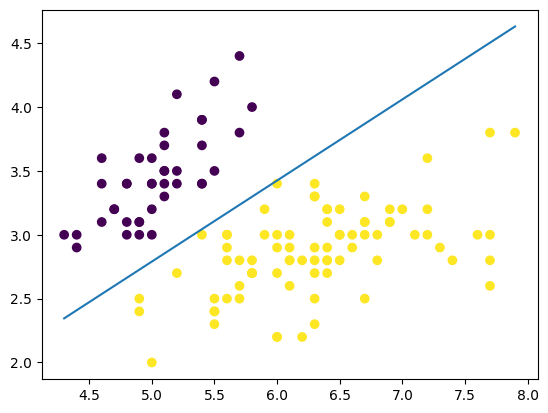

In [23]:
"""
{admonition} Oppgåve
Visualiser treningssettet og diskriminanten.
"""

plt.scatter(trening[:,0], trening[:,1], c=treningtarget)

w = lda.coef_[0]
b = lda.intercept_[0]

x = np.linspace(trening[:,0].min(), trening[:,0].max(), 100)
y = -(w[0]*x + b)/w[1]

plt.plot(x,y)
plt.show()

In [24]:
pred = lda.predict( trening )
error = pred - treningtarget
print( error )

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Legg merke til at me kan køyra prediksjonen på heile datasettet i eitt kall.

::: {admonition} Oppgåve
Kva skjer her?  Kva representerer `error`?  Kva verdi svarer til feil og kva til
rett prediksjon?
:::

For å telja feila, kan me t.d. gjera noko slikt:

In [25]:
error[ error != 0 ] = 1
print( sum(error)/len(error ) )

0.0


::: {admonition} Oppgåve
Kva representerer dette talet `sum(error)/len(error)`?
:::


## Testing

Me kan gjera akkurat den same testen som med treningssettet.

In [26]:
testpred = lda.predict( test )
testerror = testpred - testtarget
print( testerror )

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


Sjølv om me hadde perfekt prediksjon på treningssettet, får me ein
feil me testsettet.  Ein feil er derimot ikkje nok til å seia at
modellen er dårleg.  Det kan vera uflaks, eller kan henda flaks.
Dette skal me koma tilbake til med større datasett.

Det kan vera nyttig å visualisera testen òg.
På same måte som i den 
[forrige øvinga](Fisher%20Linear%20Discriminant%20in%20sklearn),
kan me definera `f` for å plotta diskriminanten.

In [27]:
x, y = lda.coef_.flatten()
z, = lda.intercept_
beta = -z/y
alpha = -x/y
def f(xx): return alpha*xx+beta

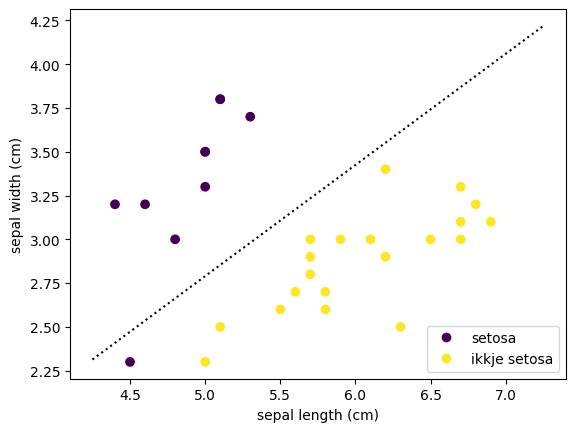

In [28]:
ax = plt.subplot()
scatter = ax.scatter(test[:, 0], test[:, 1], c=testtarget)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
ax.legend(
    scatter.legend_elements()[0], ["setosa", "ikkje setosa"], loc="lower right"
)
xv = [ 4.25 + i/2 for i in range(7) ]
yv = [ f(x) for x in xv ]
ax.plot( xv, yv, "k:" )

::: {admonition} Refleksjon
Er dette ein god modell for testsettet?
Korleis ville du ha teikna diskriminanten for å skilja dei to klassene?

Samanlikna med visualiseringa som du gjorde sjølv på treningssettet.
Er der gode grunnar for at diskriminanten ikkje er betre?
:::

::: {admonition} Merknad
Når me drog ut testsettet, tok me dei ti siste eksemplara
i kvar klasse.
Det er bør me kun gjera dersom testsettet er tilfeldig ordna.
Me risikerer at testen vert skeiv dersom blomar med uvanlege
drag ligg samla i datasettet.
Difor er det god skikk, i dei fleste tilfelle, og stokka datasettet
tilfeldig før me deler det i trenings- og testdata.
:::

## Oppgåver

::: {admonition} Oppgåva
Lag ein lineær diskriminant som bruker alle fire søylene i datasettet,
og gjerne ein diskriminant for kvar klasse.
Test diskriminanten på testsettet.
Gjev det betre klassifisering enn når me brukte to søyler?
:::

::: {admonition} Oppgåva
Kan du laga kombinasjonar av plott som lèt deg vurdera kvaliteten
på den multi-variable modellen?
:::

::: {admonition} Oppgåva
Tren ein diskriminant på tre søyler og visualiser resultatet i 3D.
Du kan finna døme ved å søka på nettet etter t.d. «3D scatter plot python».
Her er [eit døme eg fann](https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html3D).
:::

## Oppsummering

Læringsmålet i denne øvinga var å sjå korleis syntaksen
i python kan sjå ut når me skal testa ein klassifiseringsmodell 
i python.

Denne testinga er uhyre viktig.
Det skjer ofte at ein modell fungerer godt på treningssettet og
dårleg på testsettet.

Difor skal de ta med dykk desse teknikkane og prøva dei ut på større
og meir interessante datasett.

In [29]:
"""
{admonition} Oppgåva
Lag ein lineær diskriminant som bruker alle fire søylene i datasettet,
og gjerne ein diskriminant for kvar klasse.
"""
print(lda.coef_)
print(lda.intercept_)

print("feilrate: ", np.sum(testerror != 0)/len(testerror))

[[  7.54661725 -11.88675576]]
[-4.57104898]
feilrate:  0.03333333333333333


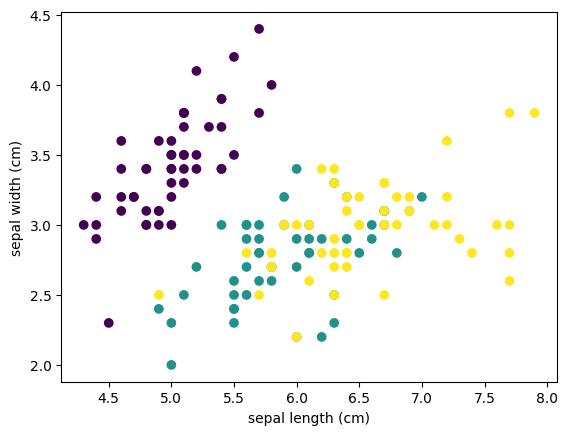

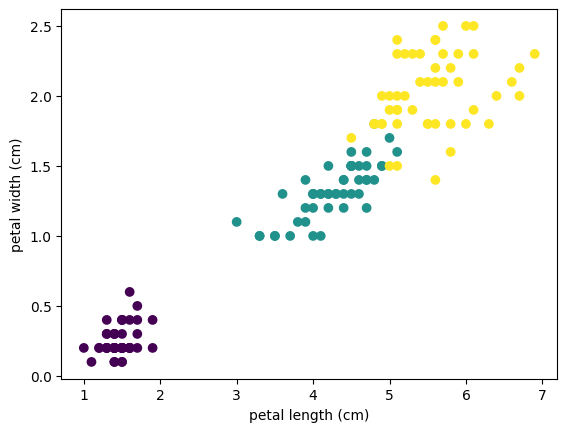

In [30]:
"""
 {admonition} Oppgåva
Kan du laga kombinasjonar av plott som lèt deg vurdera kvaliteten
på den multi-variable modellen?


"""


plt.scatter(iris.data[:,0], iris.data[:,1], c=iris.target)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

plt.scatter(iris.data[:,2], iris.data[:,3], c=iris.target)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

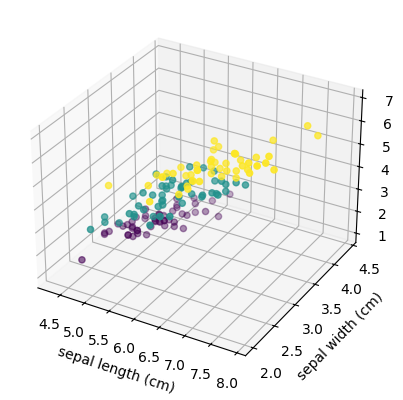

In [ ]:
"""
{admonition} Oppgåva
Tren ein diskriminant på tre søyler og visualiser resultatet i 3D.
Du kan finna døme ved å søka på nettet etter t.d. «3D scatter plot python».
Her er [eit døme eg fann](https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html3D).

"""
from mpl_toolkits.mplot3d import Axes3D

# bruker 3 var
lda.fit(iris.data[:, :3], iris.target)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(iris.data[:,0],
           iris.data[:,1],
           iris.data[:,2],
           c = iris.target)

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])

plt.show()
